Now we implement the Principal component analysis from the cleaned data that we prepared in the previous notebook

In [49]:
#These are all the required libraries for the PCA.

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [4]:
df=pd.read_csv('../data/processed/cleaned_yield_changes.csv')
df.head()

,Date,6M,1Y,2Y,3Y,5Y,7Y,10Y
0,1990-01-03,0.05,0.04,0.07,0.06,0.05,0.06,0.05
1,1990-01-04,-0.04,-0.03,-0.02,-0.03,-0.01,-0.02,-0.01
2,1990-01-05,-0.05,-0.03,-0.02,0.01,0.01,0.01,0.01
3,1990-01-08,0.03,0.02,0.00,0.01,0.00,0.02,0.03
4,1990-01-09,-0.06,-0.03,0.01,-0.01,0.00,0.00,0.00


In [5]:
#We will have to drop the date column as it is not a numerical value and will not be used in the PCA. We will also have to standardize the data before applying PCA.

x=df.drop(columns=['Date'])

scaler=StandardScaler()

x_c= scaler.fit_transform(x)

#We are following mathematical notation where x is the yield changes data, x_c is the standardized yield changes data.



In [6]:
#Now we run PCA on the standardized data.

pca=PCA()
pca_results=pca.fit_transform(x_c)

In [7]:
# Now we see some key stats

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

print(explained_variance)

    PC  Explained Variance  Cumulative Variance
0  PC1            0.813862             0.813862
1  PC2            0.125747             0.939609
2  PC3            0.033327             0.972935
3  PC4            0.014884             0.987820
4  PC5            0.005736             0.993555
5  PC6            0.003849             0.997404
6  PC7            0.002596             1.000000


So 3 PC's explain 97.2935% of the variance. Taking 3 PC's is a standard procedure. They denote level, slope and curvature movement respectively

In [8]:
#Now since we only need the first 3 pc's we re run the code setting the number of components to 3

pca=PCA(n_components=3)
pca_results=pca.fit_transform(x_c)

#just to ensure that we get the same explained variance as before we print the explained variance again.

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

print(explained_variance)

    PC  Explained Variance  Cumulative Variance
0  PC1            0.813862             0.813862
1  PC2            0.125747             0.939609
2  PC3            0.033327             0.972935


In [ ]:
#Our analysis holds true even with 3 PC's. We shouldn't expect anything different. This is a deterministic process. The PCA is a linear transformation and the first 3 PC's will always explain the same amount of variance regardless of how many PC's we choose to keep unless we change the data itself.

#Usually from what I have observed, the researchers ususally take up 2,3 and 4 PC's to compare the results. We will not do that. This whole project is to make sure conceptually we understand how the PCA works and how we implement the vasicek model to simulate the yield curve.

loadings=pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=x.columns)

print(loadings)

#The loadings are the weights of each feature in the principal components. They tell us how much each feature contributes to each principal component. The higher the absolute value of the loading, the more important that feature is in that principal component.



          PC1       PC2       PC3
6M   0.292029  0.701289  0.536785
1Y   0.361137  0.451567 -0.259281
2Y   0.398057  0.057797 -0.529450
3Y   0.406252 -0.074686 -0.323119
5Y   0.404468 -0.229689  0.024421
7Y   0.392260 -0.325434  0.267711
10Y  0.378612 -0.369727  0.433182


Its a good idea to understand what the PC'S tell us. Here is my interpretation of it. We know that PC1, 2 3 give us level, slope and curvature. Here is what their values tell us

PC	Interpretation	Why
PC1	Level factor	All maturities are positive and fairly similar
PC2	Slope factor	Short maturities are positive, long maturities are negative
PC3	Curvature factor	Short and long ends are positive, middle maturities are negative

A broad strokes, high level interpretation is

On most days the maturities move together. They rise and fall together. This explains the bulk of the movement (PC1)

Sometimes the short rates and long rates move in opposite direction (PC2)

middle maturities behave differently in comparison to short and long maturities (PC3)

In [18]:
loadings.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 6M to 10Y
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     7 non-null      float64
 1   PC2     7 non-null      float64
 2   PC3     7 non-null      float64
dtypes: float64(3)
memory usage: 540.0 bytes


In [ ]:
#Now we need PC scores which are the projections of the original data onto the principal components.

pc_scores=pd.DataFrame(pca_results, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=df.index)


#PC scores tell you the amount of movement on each date.


#We need to attach a date column to the pc_scores dataframe so that we can plot the pc scores over time.

pc_scores=pd.concat([df['Date'], pc_scores], axis=1)

pc_scores["Date"] = pd.to_datetime(pc_scores["Date"])

pc_scores.info()



<class 'pandas.DataFrame'>
RangeIndex: 8505 entries, 0 to 8504
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    8505 non-null   datetime64[us]
 1   PC1     8505 non-null   float64       
 2   PC2     8505 non-null   float64       
 3   PC3     8505 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 265.9 KB


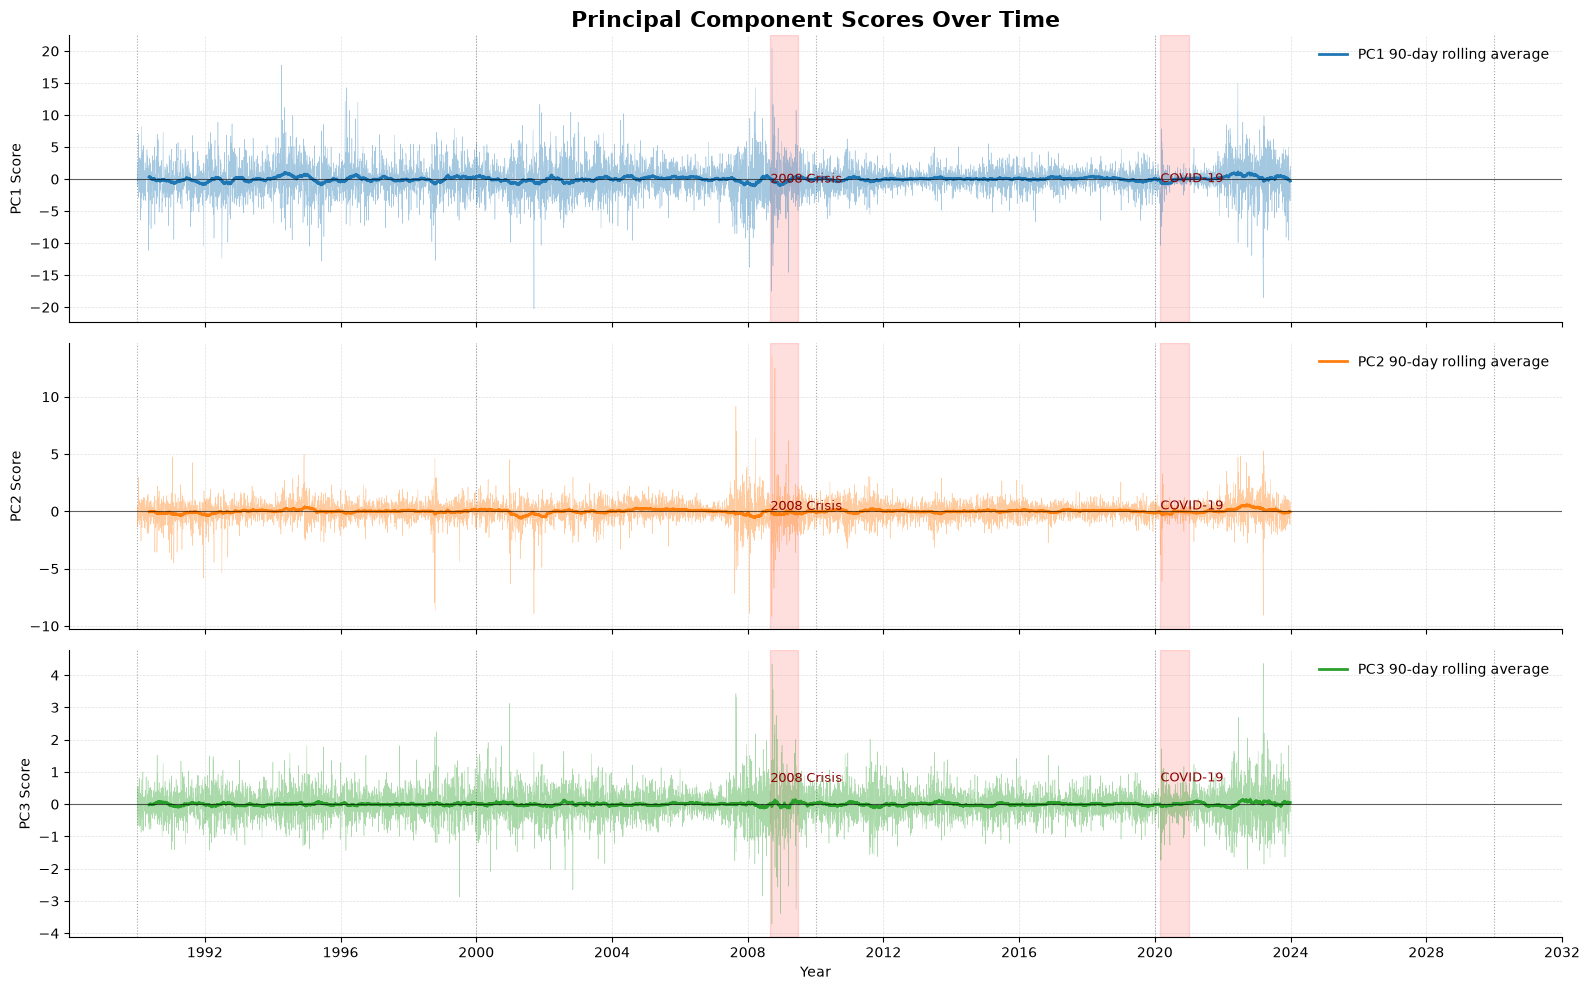

In [47]:
#We should plot the pc scores over time to see how they change over time. We will also add some shading to indicate stress periods in the market.
import matplotlib.dates as mdates

pc_scores["Date"] = pd.to_datetime(pc_scores["Date"])
pc_scores = pc_scores.sort_values("Date")

stress_periods = {
    "2008 Crisis": ("2008-09-01", "2009-06-30"),
    "COVID-19": ("2020-03-01", "2020-12-31")
}

pcs = ["PC1", "PC2", "PC3"]

colors = {
    "PC1": "#1f77b4",
    "PC2": "#ff7f0e",
    "PC3": "#2ca02c"
}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, pc in zip(axes, pcs):

    # Decade separators
    for year in range(1990, 2031, 10):
        ax.axvline(
            pd.to_datetime(f"{year}-01-01"),
            color="black",
            linestyle=":",
            linewidth=0.8,
            alpha=0.35
        )

    # Stress period shading
    for label, (start, end) in stress_periods.items():
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)

        ax.axvspan(
            start,
            end,
            color="red",
            alpha=0.13
        )

        ax.text(
            start,
            ax.get_ylim()[1],
            label,
            fontsize=9,
            color="darkred",
            verticalalignment="top"
        )

    # Raw daily PC scores - very faint
    ax.plot(
        pc_scores["Date"],
        pc_scores[pc],
        color=colors[pc],
        linewidth=0.35,
        alpha=0.4
    )

    # 90-day rolling average - main story line
    ax.plot(
        pc_scores["Date"],
        pc_scores[pc].rolling(90).mean(),
        color=colors[pc],
        linewidth=2.0,
        label=f"{pc} 90-day rolling average"
    )

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)

    ax.set_ylabel(f"{pc} Score")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
    ax.legend(loc="upper right", frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_title(
    "Principal Component Scores Over Time",
    fontsize=16,
    weight="bold"
)

axes[-1].set_xlabel("Year")

axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

In [ ]:
#Now we will run a regression of the pc scores against the yield changes to see how much of the yield changes can be explained by the pc scores. We will use the first 3 pc scores as independent variables and the yield changes as dependent variables. We will run a regression for each tenor separately.

'''PC1_beta is the sensitivity of the yield change to the first principal component, 

PC2_beta is the sensitivity of the yield change to the second principal component, and 

PC3_beta is the sensitivity of the yield change to the third principal component. 

The intercept is the expected yield change when all principal components are zero. 

R2 is the coefficient of determination which tells us how much of the variance in the yield changes can be explained by the principal components.'''

tenors=["6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]

X=pc_scores[["PC1", "PC2", "PC3"]]
Y=df[tenors]

regression_results = []

for tenor in tenors:
    model=LinearRegression()
    model.fit(X, Y[tenor])

    regression_results.append({
        "Tenor": tenor,
        "Intercept": model.intercept_,
        "PC1_Beta": model.coef_[0],
        "PC2_Beta": model.coef_[1],
        "PC3_Beta": model.coef_[2],
        "R2": model.score(X, Y[tenor])
    })

regression_df=pd.DataFrame(regression_results)

regression_df

,Tenor,Intercept,PC1_Beta,PC2_Beta,PC3_Beta,R2
0,6M,-0.000309,0.012029,0.028887,0.022111,0.985969
1,1Y,-0.000355,0.016282,0.020359,-0.011690,0.938180
2,2Y,-0.000428,0.022298,0.003238,-0.029658,0.971027
3,3Y,-0.000457,0.023922,-0.004398,-0.019026,0.969507
4,5Y,-0.000474,0.024823,-0.014096,0.001499,0.978578
5,7Y,-0.000482,0.024036,-0.019941,0.016404,0.986533
6,10Y,-0.000477,0.022096,-0.021577,0.025280,0.980755


In [ ]:
#Now we will stress test the results for up and down stress scenarios

#recall that the upstress scenario is the 99.5th percentile of the pc scores and the downstress scenario is the 0.5th percentile of the pc scores. We will use these values to calculate the expected yield changes under these stress scenarios.

#we take the 0.5th percentile and 99.5th percentile of the pc scores to get the stress scenarios. we want to ensure that the portfolio is robust to extreme market conditions. We will use these stress scenarios to calculate the expected yield changes under these scenarios.

pc_stress=pc_scores[["PC1", "PC2", "PC3"]].quantile([0.005, 0.995])

pc_stress


,PC1,PC2,PC3
0.005,-7.742033,-3.565659,-1.429818
0.995,7.670867,2.937325,1.588100
